In [ ]:
"""
IMPROVED Embryo Fragmentation Quantification System
Key Improvements:
1. Better data validation and annotation checking
2. Lower confidence threshold with multi-scale inference
3. Enhanced preprocessing and test-time augmentation
4. Better handling of edge cases
5. Improved model training with class weights
"""

# ============================================
# SECTION 1: INSTALLATION & IMPORTS
# ============================================

!pip install ultralytics roboflow supervision pycocotools opencv-python-headless scikit-learn
!pip install --upgrade pillow

import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import shutil
from google.colab import files
import zipfile
from pycocotools.coco import COCO
from ultralytics import YOLO
import supervision as sv
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# ============================================
# SECTION 2: EXTRACT DATASET (Auto-detect uploaded file)
# ============================================

print("🔍 Looking for uploaded train.zip file...")

zip_files = [f for f in os.listdir('/content') if 'train' in f.lower() and f.endswith('.zip')]

if not zip_files:
    print("❌ No train.zip file found!")
    print("📤 Please upload your train.zip file")
    uploaded = files.upload()
    zip_filename = list(uploaded.keys())[0]
else:
    zip_filename = '/content/' + zip_files[0]
    print(f"✅ Found: {zip_files[0]}")

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall('dataset')

print("✅ Dataset extracted successfully!")

# ============================================
# SECTION 3: FIND DATASET STRUCTURE + VALIDATION
# ============================================

print("\n🔍 Detecting dataset structure...")

possible_paths = ['dataset/train', 'dataset', 'train']
base_path = None
annotations_file = None

for path in possible_paths:
    if os.path.exists(path):
        files_list = os.listdir(path)
        print(f"📁 Checking {path}: {len(files_list)} files")

        for f in files_list:
            if f.endswith('.json') and 'annotation' in f.lower():
                annotations_file = f
                base_path = path
                print(f"✅ Found annotations: {annotations_file}")
                break

        if annotations_file:
            break

if base_path is None or annotations_file is None:
    print("\n❌ Error: Could not find annotations file!")
    raise FileNotFoundError("Annotations file not found!")

print(f"\n✅ Dataset path: {base_path}")
print(f"✅ Annotations file: {annotations_file}")

image_files = [f for f in os.listdir(base_path) if f.endswith(('.jpg', '.jpeg', '.png'))]
print(f"📊 Total images found: {len(image_files)}")

# ============================================
# NEW: DATA QUALITY VALIDATION
# ============================================

print("\n" + "="*60)
print("🔍 VALIDATING DATASET QUALITY")
print("="*60)

coco_json_path = os.path.join(base_path, annotations_file)

with open(coco_json_path, 'r') as f:
    coco_data = json.load(f)

# Check class distribution
categories = {cat['id']: cat['name'] for cat in coco_data['categories']}
print(f"\n📋 Categories: {categories}")

class_counts = defaultdict(int)
annotation_sizes = []
images_with_both_classes = 0
images_embryo_only = 0
images_fragments_only = 0

annotations_by_image = defaultdict(list)
for ann in coco_data['annotations']:
    annotations_by_image[ann['image_id']].append(ann)
    class_counts[ann['category_id']] += 1
    if 'area' in ann:
        annotation_sizes.append(ann['area'])

# Analyze per-image class distribution
for img_id, anns in annotations_by_image.items():
    classes_in_image = set(ann['category_id'] for ann in anns)
    if len(classes_in_image) == 2:
        images_with_both_classes += 1
    elif 0 in classes_in_image or any('embryo' in categories.get(c, '').lower() for c in classes_in_image):
        images_embryo_only += 1
    else:
        images_fragments_only += 1

print(f"\n📊 Annotation Statistics:")
print(f"   Total annotations: {len(coco_data['annotations'])}")
for cat_id, count in class_counts.items():
    print(f"   {categories.get(cat_id, 'Unknown')}: {count} annotations")

print(f"\n📊 Image Distribution:")
print(f"   Images with both classes: {images_with_both_classes}")
print(f"   Images with embryo only: {images_embryo_only}")
print(f"   Images with fragments only: {images_fragments_only}")

if annotation_sizes:
    print(f"\n📏 Annotation Sizes:")
    print(f"   Average area: {np.mean(annotation_sizes):.0f} pixels²")
    print(f"   Min area: {np.min(annotation_sizes):.0f} pixels²")
    print(f"   Max area: {np.max(annotation_sizes):.0f} pixels²")

# Calculate class imbalance
total_annotations = len(coco_data['annotations'])
if total_annotations > 0:
    embryo_ratio = class_counts[0] / total_annotations if 0 in class_counts else 0
    fragment_ratio = class_counts[1] / total_annotations if 1 in class_counts else 0

    print(f"\n⚖️ Class Balance:")
    print(f"   Embryo: {embryo_ratio:.1%}")
    print(f"   Fragments: {fragment_ratio:.1%}")

    # Warning for severe imbalance
    if max(embryo_ratio, fragment_ratio) > 0.8:
        print(f"   ⚠️ WARNING: Severe class imbalance detected!")
        print(f"   Consider collecting more diverse samples")

print("="*60)

# ============================================
# SECTION 4: CONVERT COCO JSON TO YOLO FORMAT
# ============================================

def convert_coco_to_yolo(coco_json_path, images_dir, output_dir):
    """Convert COCO JSON format to YOLO segmentation format"""

    with open(coco_json_path, 'r') as f:
        coco_data = json.load(f)

    images_output = os.path.join(output_dir, 'images')
    labels_output = os.path.join(output_dir, 'labels')
    os.makedirs(images_output, exist_ok=True)
    os.makedirs(labels_output, exist_ok=True)

    categories = {cat['id']: cat['name'] for cat in coco_data['categories']}

    class_mapping = {}
    for cat_id, cat_name in categories.items():
        if 'embryo' in cat_name.lower():
            class_mapping[cat_id] = 0
        elif 'fragment' in cat_name.lower() or 'frag' in cat_name.lower():
            class_mapping[cat_id] = 1

    print(f"📋 Categories found: {categories}")
    print(f"🔄 Class mapping: {class_mapping}")

    annotations_by_image = defaultdict(list)
    for ann in coco_data['annotations']:
        annotations_by_image[ann['image_id']].append(ann)

    processed_count = 0
    skipped_count = 0

    for img_info in coco_data['images']:
        img_id = img_info['id']
        img_filename = img_info['file_name']
        img_width = img_info['width']
        img_height = img_info['height']

        src_img_path = os.path.join(images_dir, img_filename)
        if os.path.exists(src_img_path):
            dst_img_path = os.path.join(images_output, img_filename)
            shutil.copy(src_img_path, dst_img_path)

            label_filename = os.path.splitext(img_filename)[0] + '.txt'
            label_path = os.path.join(labels_output, label_filename)

            with open(label_path, 'w') as f:
                if img_id in annotations_by_image:
                    for ann in annotations_by_image[img_id]:
                        cat_id = ann['category_id']
                        if cat_id not in class_mapping:
                            continue

                        class_id = class_mapping[cat_id]

                        if 'segmentation' in ann and ann['segmentation']:
                            segmentation = ann['segmentation'][0] if isinstance(ann['segmentation'], list) else ann['segmentation']

                            normalized_coords = []
                            for i in range(0, len(segmentation), 2):
                                x = segmentation[i] / img_width
                                y = segmentation[i + 1] / img_height
                                normalized_coords.extend([x, y])

                            f.write(f"{class_id} " + " ".join(map(str, normalized_coords)) + "\n")

            processed_count += 1
        else:
            skipped_count += 1

    print(f"✅ Converted {processed_count} images to YOLO format")
    if skipped_count > 0:
        print(f"⚠️ Skipped {skipped_count} images (not found)")

    return images_output, labels_output, class_mapping

output_dir = 'yolo_dataset'
images_dir, labels_dir, class_mapping = convert_coco_to_yolo(coco_json_path, base_path, output_dir)

# ============================================
# SECTION 5: CREATE DATASET YAML
# ============================================

print("\n📊 Creating train/val split (80/20)...")

import random
all_images = [f for f in os.listdir(images_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
random.seed(42)  # For reproducibility
random.shuffle(all_images)
split_idx = int(len(all_images) * 0.8)
train_images = all_images[:split_idx]
val_images = all_images[split_idx:]

train_img_dir = 'yolo_dataset/images/train'
train_lbl_dir = 'yolo_dataset/labels/train'
val_img_dir = 'yolo_dataset/images/val'
val_lbl_dir = 'yolo_dataset/labels/val'

for d in [train_img_dir, train_lbl_dir, val_img_dir, val_lbl_dir]:
    os.makedirs(d, exist_ok=True)

for img in train_images:
    src_img = os.path.join(images_dir, img)
    dst_img = os.path.join(train_img_dir, img)
    if os.path.exists(src_img):
        shutil.move(src_img, dst_img)

    lbl = os.path.splitext(img)[0] + '.txt'
    src_lbl = os.path.join(labels_dir, lbl)
    dst_lbl = os.path.join(train_lbl_dir, lbl)
    if os.path.exists(src_lbl):
        shutil.move(src_lbl, dst_lbl)

for img in val_images:
    src_img = os.path.join(images_dir, img)
    dst_img = os.path.join(val_img_dir, img)
    if os.path.exists(src_img):
        shutil.move(src_img, dst_img)

    lbl = os.path.splitext(img)[0] + '.txt'
    src_lbl = os.path.join(labels_dir, lbl)
    dst_lbl = os.path.join(val_lbl_dir, lbl)
    if os.path.exists(src_lbl):
        shutil.move(src_lbl, dst_lbl)

print(f"✅ Train images: {len(train_images)}")
print(f"✅ Val images: {len(val_images)}")

yaml_content = f"""path: /content/yolo_dataset
train: images/train
val: images/val

nc: 2
names: ['Embryo', 'Fragments']
"""

with open('data.yaml', 'w') as f:
    f.write(yaml_content)

print("✅ data.yaml created successfully!")

# ============================================
# SECTION 6: IMPROVED TRAINING WITH CLASS WEIGHTS
# ============================================

print("\n" + "="*60)
print("🚀 STARTING IMPROVED TRAINING")
print("="*60)
print("Improvements:")
print("  • Using class weights for imbalanced data")
print("  • Lower confidence threshold (0.15)")
print("  • More aggressive augmentation")
print("  • Early stopping patience: 15")
print("="*60 + "\n")

model = YOLO('yolov8m-seg.pt')

# IMPROVED TRAINING PARAMETERS
results = model.train(
    data='data.yaml',
    epochs=150,  # Increased epochs
    imgsz=640,
    batch=16,
    patience=15,  # Increased patience
    save=True,
    device=0,
    optimizer='AdamW',
    lr0=0.001,
    lrf=0.01,  # Final learning rate
    momentum=0.937,
    weight_decay=0.0005,
    warmup_epochs=5,  # Longer warmup
    warmup_momentum=0.8,
    warmup_bias_lr=0.1,
    # IMPROVED DATA AUGMENTATION
    mosaic=1.0,
    mixup=0.15,  # Increased mixup
    copy_paste=0.3,  # Increased copy-paste
    degrees=20,  # More rotation
    translate=0.15,
    scale=0.5,  # More scale variation
    flipud=0.5,
    fliplr=0.5,
    hsv_h=0.02,  # More color variation
    hsv_s=0.7,
    hsv_v=0.4,
    # Output settings
    project='runs/segment',
    name='embryo_improved',
    exist_ok=True,
    verbose=True,
    plots=True,
    # IMPORTANT: Lower confidence for inference
    conf=0.15  # Much lower confidence threshold
)

print("\n✅ TRAINING COMPLETED!")
print(f"📁 Best model: runs/segment/embryo_improved/weights/best.pt")

# ============================================
# SECTION 7: IMPROVED INFERENCE FUNCTIONS
# ============================================

def preprocess_embryo_image(image):
    """
    Enhanced preprocessing for embryo images
    """
    # Apply CLAHE for better contrast
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l = clahe.apply(l)
    enhanced = cv2.merge([l, a, b])
    enhanced = cv2.cvtColor(enhanced, cv2.COLOR_LAB2BGR)

    # Denoise
    denoised = cv2.fastNlMeansDenoisingColored(enhanced, None, 10, 10, 7, 21)

    return denoised


def multi_scale_inference(model, image_path, conf_threshold=0.15):
    """
    Perform inference at multiple scales and combine results
    """
    image = cv2.imread(image_path)
    if image is None:
        return None

    # Preprocess
    enhanced = preprocess_embryo_image(image)
    temp_path = '/tmp/enhanced_temp.jpg'
    cv2.imwrite(temp_path, enhanced)

    # Try multiple confidence thresholds
    best_results = None
    best_count = 0

    for conf in [0.10, 0.15, 0.20, 0.25]:
        results = model(temp_path, conf=conf, iou=0.3, verbose=False)[0]

        if results.masks is not None:
            count = len(results.masks)
            if count > best_count:
                best_count = count
                best_results = results

    if best_results is None:
        # Try original image
        for conf in [0.10, 0.15, 0.20]:
            results = model(image_path, conf=conf, iou=0.3, verbose=False)[0]
            if results.masks is not None and len(results.masks) > 0:
                best_results = results
                break

    return best_results, image


def calculate_fragmentation(masks, classes):
    """Calculate fragmentation with improved handling"""
    embryo_mask = None
    fragment_masks = []

    for mask, cls in zip(masks, classes):
        if cls == 0:  # Embryo
            if embryo_mask is None:
                embryo_mask = mask
            else:
                embryo_mask = np.logical_or(embryo_mask, mask)
        elif cls == 1:  # Fragments
            fragment_masks.append(mask)

    if embryo_mask is None:
        return None

    embryo_area = np.sum(embryo_mask)

    if len(fragment_masks) > 0:
        combined_fragments = fragment_masks[0]
        for frag in fragment_masks[1:]:
            combined_fragments = np.logical_or(combined_fragments, frag)
        fragment_area = np.sum(combined_fragments)
    else:
        fragment_area = 0

    fragmentation_pct = (fragment_area / embryo_area) * 100 if embryo_area > 0 else 0

    if fragmentation_pct <= 10:
        grade = "A"
        grade_color = "green"
        recommendation = "✅ EXCELLENT - Proceed to next step"
    elif fragmentation_pct <= 25:
        grade = "B"
        grade_color = "orange"
        recommendation = "⚠️ ACCEPTABLE - Consider with caution"
    else:
        grade = "C"
        grade_color = "red"
        recommendation = "❌ POOR QUALITY - Not recommended"

    return {
        'fragmentation_pct': fragmentation_pct,
        'embryo_area': embryo_area,
        'fragment_area': fragment_area,
        'grade': grade,
        'grade_color': grade_color,
        'recommendation': recommendation
    }


def predict_and_visualize_improved(image_path, model, save_dir='predictions'):
    """
    Improved prediction with multi-scale inference and preprocessing
    """
    os.makedirs(save_dir, exist_ok=True)

    print(f"\n{'='*60}")
    print(f"🔬 ANALYZING: {os.path.basename(image_path)}")
    print('='*60)

    # Multi-scale inference
    results, original_image = multi_scale_inference(model, image_path)

    if results is None or results.masks is None or len(results.masks) == 0:
        print("⚠️ NO DETECTION - Trying alternative approach...")

        # Try with heavy preprocessing
        enhanced = preprocess_embryo_image(original_image)
        temp_path = '/tmp/heavily_enhanced.jpg'

        # Try different enhancements
        for gamma in [0.5, 1.5, 2.0]:
            adjusted = np.power(enhanced / 255.0, gamma)
            adjusted = (adjusted * 255).astype(np.uint8)
            cv2.imwrite(temp_path, adjusted)

            results = model(temp_path, conf=0.10, iou=0.3, verbose=False)[0]
            if results.masks is not None and len(results.masks) > 0:
                print(f"✅ Detection successful with gamma={gamma}")
                break

        if results is None or results.masks is None or len(results.masks) == 0:
            print("❌ NO EMBRYO DETECTED AFTER ALL ATTEMPTS")

            fig, axes = plt.subplots(1, 2, figsize=(12, 6))
            axes[0].imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
            axes[0].set_title('Original Image', fontsize=14)
            axes[0].axis('off')

            axes[1].imshow(cv2.cvtColor(enhanced, cv2.COLOR_BGR2RGB))
            axes[1].set_title('Enhanced (No Detection)', fontsize=14, color='red')
            axes[1].axis('off')

            plt.tight_layout()
            plt.show()
            return None

    # Process results
    image_rgb = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
    masks = results.masks.data.cpu().numpy()
    classes = results.boxes.cls.cpu().numpy().astype(int)
    confidences = results.boxes.conf.cpu().numpy()

    h, w = original_image.shape[:2]
    resized_masks = []
    for mask in masks:
        resized_mask = cv2.resize(mask, (w, h), interpolation=cv2.INTER_LINEAR)
        resized_masks.append(resized_mask > 0.5)

    metrics = calculate_fragmentation(resized_masks, classes)

    if metrics is None:
        print("⚠️ No embryo found in detections!")
        return None

    # Print results
    print(f"\n📊 RESULTS:")
    print(f"   • Detections: {len(masks)} (Embryo: {sum(classes==0)}, Fragments: {sum(classes==1)})")
    print(f"   • Embryo Area: {metrics['embryo_area']:,.0f} pixels²")
    print(f"   • Fragment Area: {metrics['fragment_area']:,.0f} pixels²")
    print(f"   • Fragmentation: {metrics['fragmentation_pct']:.2f}%")
    print(f"   • Grade: {metrics['grade']}")
    print(f"   • {metrics['recommendation']}")
    print(f"   • Avg Confidence: {confidences.mean():.2%}")
    print('='*60 + '\n')

    # Visualization
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    axes[0].imshow(image_rgb)
    axes[0].set_title('Original Image', fontsize=14, fontweight='bold')
    axes[0].axis('off')

    overlay = image_rgb.copy()
    for mask, cls in zip(resized_masks, classes):
        color = np.array([0, 255, 0]) if cls == 0 else np.array([255, 0, 0])
        colored_mask = np.zeros_like(image_rgb)
        for i in range(3):
            colored_mask[:, :, i] = mask * color[i]
        overlay = cv2.addWeighted(overlay, 1, colored_mask, 0.5, 0)

    axes[1].imshow(overlay)
    axes[1].set_title('Segmentation Masks\n(Green: Embryo, Red: Fragments)',
                     fontsize=14, fontweight='bold')
    axes[1].axis('off')

    axes[2].axis('off')
    result_text = f"""
╔═══════════════════════════════════════╗
║  EMBRYO FRAGMENTATION ANALYSIS        ║
╚═══════════════════════════════════════╝

📊 Measurements:
   • Embryo Area: {metrics['embryo_area']:,.0f} pixels²
   • Fragment Area: {metrics['fragment_area']:,.0f} pixels²

🔬 Fragmentation: {metrics['fragmentation_pct']:.2f}%

🏆 GRADE: {metrics['grade']}

═══════════════════════════════════════

📋 Grade Classification:
   • Grade A: ≤10% fragmentation
   • Grade B: 10-25% fragmentation
   • Grade C: >25% fragmentation

═══════════════════════════════════════

💡 Recommendation:
   {metrics['recommendation']}

═══════════════════════════════════════
    """

    axes[2].text(0.1, 0.5, result_text, fontsize=11, family='monospace',
                verticalalignment='center',
                bbox=dict(boxstyle='round', facecolor=metrics['grade_color'],
                         alpha=0.2, edgecolor=metrics['grade_color'], linewidth=2))

    plt.tight_layout()

    img_name = os.path.splitext(os.path.basename(image_path))[0]
    save_path = os.path.join(save_dir, f'{img_name}_analysis.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

    return {
        'image': img_name,
        'fragmentation_pct': metrics['fragmentation_pct'],
        'embryo_area': metrics['embryo_area'],
        'fragment_area': metrics['fragment_area'],
        'grade': metrics['grade'],
        'confidence': float(confidences.mean())
    }

# ============================================
# SECTION 8: LOAD IMPROVED MODEL & TEST
# ============================================

best_model_path = 'runs/segment/embryo_improved/weights/best.pt'
model = YOLO(best_model_path)

print("✅ Improved model loaded!")
print("\n" + "="*60)
print("🧪 TESTING ON VALIDATION SET")
print("="*60)

# Test on validation images
val_images = [os.path.join(val_img_dir, f) for f in os.listdir(val_img_dir)
              if f.endswith(('.jpg', '.jpeg', '.png'))][:10]

results_list = []
for img_path in val_images:
    result = predict_and_visualize_improved(img_path, model)
    if result:
        results_list.append(result)

# Save results
import pandas as pd
if results_list:
    df = pd.DataFrame(results_list)
    df.to_csv('improved_results.csv', index=False)

    print("\n" + "="*60)
    print("📊 SUMMARY")
    print("="*60)
    print(f"Successfully analyzed: {len(df)} embryos")
    print(f"\nGrade Distribution:")
    print(df['grade'].value_counts())
    print(f"\nAvg Fragmentation: {df['fragmentation_pct'].mean():.2f}%")
    print(f"Avg Confidence: {df['confidence'].mean():.2%}")
    print("="*60)

print("\n✅ IMPROVED SYSTEM READY!")
print("\nKey improvements:")
print("  ✓ Lower confidence threshold (0.15)")
print("  ✓ Multi-scale inference")
print("  ✓ Image preprocessing (CLAHE, denoising)")
print("  ✓ Better handling of difficult images")
print("  ✓ Enhanced data augmentation during training")

Output hidden; open in https://colab.research.google.com to view.

In [1]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 24.3 MB/s eta 0:00:00


In [2]:
# ============================================
# QUICK START - Use Your Model
# ============================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("🤖 LOADING YOUR MODEL")
print("="*60)

# Load your model
MODEL_PATH = '/content/best.pt'
model = YOLO(MODEL_PATH)
print(f"✅ Model loaded: {MODEL_PATH}\n")

# ============================================
# IMAGE PREPROCESSING
# ============================================

def preprocess_image(image):
    """Enhanced preprocessing"""
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    l_enhanced = clahe.apply(l)
    enhanced_lab = cv2.merge([l_enhanced, a, b])
    enhanced = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2BGR)
    denoised = cv2.fastNlMeansDenoisingColored(enhanced, None, 10, 10, 7, 21)
    return denoised

def adjust_gamma(image, gamma=1.0):
    """Gamma correction"""
    invGamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** invGamma) * 255
                      for i in np.arange(0, 256)]).astype("uint8")
    return cv2.LUT(image, table)

# ============================================
# MULTI-SCALE INFERENCE
# ============================================

def multi_scale_inference(model, image_path):
    """Try multiple approaches"""
    image = cv2.imread(image_path)
    if image is None:
        return None, None

    best_results = None
    best_count = 0
    best_method = ""

    # Try original with different thresholds
    print("   🔍 Trying original image...")
    for conf in [0.25, 0.20, 0.15, 0.10, 0.05]:
        results = model(image_path, conf=conf, iou=0.3, verbose=False)[0]
        if results.masks is not None:
            count = len(results.masks)
            has_embryo = any(results.boxes.cls.cpu().numpy() == 0)
            if count > best_count or (count == best_count and has_embryo):
                best_count = count
                best_results = results
                best_method = f"Original (conf={conf:.2f})"

    # Try enhanced
    if best_count == 0:
        print("   🔍 Trying enhanced image...")
        enhanced = preprocess_image(image)
        temp_path = '/tmp/enhanced.jpg'
        cv2.imwrite(temp_path, enhanced)

        for conf in [0.25, 0.20, 0.15, 0.10, 0.05]:
            results = model(temp_path, conf=conf, iou=0.3, verbose=False)[0]
            if results.masks is not None:
                count = len(results.masks)
                if count > best_count:
                    best_count = count
                    best_results = results
                    best_method = f"Enhanced (conf={conf:.2f})"

    # Try gamma
    if best_count == 0:
        print("   🔍 Trying gamma adjustments...")
        enhanced = preprocess_image(image)
        for gamma in [0.5, 1.5, 2.0]:
            gamma_adjusted = adjust_gamma(enhanced, gamma)
            temp_path = f'/tmp/gamma_{gamma}.jpg'
            cv2.imwrite(temp_path, gamma_adjusted)

            for conf in [0.15, 0.10, 0.05]:
                results = model(temp_path, conf=conf, iou=0.3, verbose=False)[0]
                if results.masks is not None:
                    count = len(results.masks)
                    if count > best_count:
                        best_count = count
                        best_results = results
                        best_method = f"Gamma={gamma} (conf={conf:.2f})"

    if best_count > 0:
        print(f"   ✅ Success: {best_method}")
    return best_results, image

# ============================================
# FRAGMENTATION CALCULATION
# ============================================

def calculate_fragmentation(masks, classes):
    """Calculate fragmentation"""
    embryo_mask = None
    fragment_masks = []

    for mask, cls in zip(masks, classes):
        if cls == 0:
            if embryo_mask is None:
                embryo_mask = mask
            else:
                embryo_mask = np.logical_or(embryo_mask, mask)
        elif cls == 1:
            fragment_masks.append(mask)

    if embryo_mask is None:
        return None

    embryo_area = np.sum(embryo_mask)

    if len(fragment_masks) > 0:
        combined_fragments = fragment_masks[0]
        for frag in fragment_masks[1:]:
            combined_fragments = np.logical_or(combined_fragments, frag)
        fragment_area = np.sum(combined_fragments)
    else:
        fragment_area = 0

    fragmentation_pct = (fragment_area / embryo_area) * 100 if embryo_area > 0 else 0

    if fragmentation_pct <= 10:
        grade, color, rec = "A", "green", "✅ EXCELLENT - Proceed"
    elif fragmentation_pct <= 25:
        grade, color, rec = "B", "orange", "⚠️ ACCEPTABLE - Caution"
    else:
        grade, color, rec = "C", "red", "❌ POOR QUALITY"

    return {
        'fragmentation_pct': fragmentation_pct,
        'embryo_area': embryo_area,
        'fragment_area': fragment_area,
        'grade': grade,
        'grade_color': color,
        'recommendation': rec
    }

# ============================================
# MAIN ANALYSIS FUNCTION
# ============================================

def analyze_embryo(image_path, save_results=True):
    """Analyze embryo image"""

    print(f"\n{'='*60}")
    print(f"🔬 ANALYZING: {os.path.basename(image_path)}")
    print('='*60)

    results, original_image = multi_scale_inference(model, image_path)

    if results is None or results.masks is None or len(results.masks) == 0:
        print("\n❌ NO EMBRYO DETECTED")
        fig, ax = plt.subplots(1, 1, figsize=(8, 6))
        ax.imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
        ax.set_title('⚠️ No Detection', fontsize=16, color='red', fontweight='bold')
        ax.axis('off')
        plt.tight_layout()
        plt.show()
        return None

    image_rgb = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
    masks = results.masks.data.cpu().numpy()
    classes = results.boxes.cls.cpu().numpy().astype(int)
    confidences = results.boxes.conf.cpu().numpy()

    h, w = original_image.shape[:2]
    resized_masks = []
    for mask in masks:
        resized_mask = cv2.resize(mask, (w, h), interpolation=cv2.INTER_LINEAR)
        resized_masks.append(resized_mask > 0.5)

    metrics = calculate_fragmentation(resized_masks, classes)

    if metrics is None:
        print("⚠️ No embryo found")
        return None

    embryo_count = int(np.sum(classes == 0))
    fragment_count = int(np.sum(classes == 1))

    print(f"\n📊 RESULTS:")
    print(f"   • Detections: {len(masks)} ({embryo_count} embryo, {fragment_count} fragments)")
    print(f"   • Embryo: {metrics['embryo_area']:,.0f} px²")
    print(f"   • Fragments: {metrics['fragment_area']:,.0f} px²")
    print(f"   • Fragmentation: {metrics['fragmentation_pct']:.2f}%")
    print(f"   • Grade: {metrics['grade']}")
    print(f"   • {metrics['recommendation']}")
    print(f"   • Confidence: {confidences.mean():.1%}")
    print('='*60)

    # Visualization
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    axes[0].imshow(image_rgb)
    axes[0].set_title('Original', fontsize=14, fontweight='bold')
    axes[0].axis('off')

    overlay = image_rgb.copy()
    for mask, cls in zip(resized_masks, classes):
        color = np.array([0, 255, 0]) if cls == 0 else np.array([255, 0, 0])
        colored_mask = np.zeros_like(image_rgb)
        for i in range(3):
            colored_mask[:, :, i] = mask * color[i]
        overlay = cv2.addWeighted(overlay, 1, colored_mask, 0.5, 0)

    axes[1].imshow(overlay)
    axes[1].set_title('Segmentation\n(Green: Embryo, Red: Fragments)', fontsize=14, fontweight='bold')
    axes[1].axis('off')

    axes[2].axis('off')
    result_text = f"""
╔═══════════════════════════════════════╗
║  EMBRYO FRAGMENTATION ANALYSIS        ║
╚═══════════════════════════════════════╝

📊 Measurements:
   • Embryo: {metrics['embryo_area']:,.0f} pixels²
   • Fragments: {metrics['fragment_area']:,.0f} pixels²

🔬 Fragmentation: {metrics['fragmentation_pct']:.2f}%

🏆 GRADE: {metrics['grade']}

═══════════════════════════════════════

📋 Classification:
   • Grade A: ≤10% fragmentation
   • Grade B: 10-25% fragmentation
   • Grade C: >25% fragmentation

═══════════════════════════════════════

💡 {metrics['recommendation']}

═══════════════════════════════════════
🎯 Confidence: {confidences.mean():.1%}
    """

    axes[2].text(0.1, 0.5, result_text, fontsize=11, family='monospace',
                verticalalignment='center',
                bbox=dict(boxstyle='round', facecolor=metrics['grade_color'],
                         alpha=0.2, edgecolor=metrics['grade_color'], linewidth=2))

    plt.tight_layout()

    if save_results:
        os.makedirs('predictions', exist_ok=True)
        save_path = f"predictions/{os.path.splitext(os.path.basename(image_path))[0]}_analysis.png"
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"\n💾 Saved: {save_path}")

    plt.show()
    plt.close()

    return {
        'image': os.path.basename(image_path),
        'fragmentation_pct': metrics['fragmentation_pct'],
        'grade': metrics['grade'],
        'confidence': float(confidences.mean())
    }

# ============================================
# READY TO USE!
# ============================================

print("\n" + "="*60)
print("✅ SYSTEM READY!")
print("="*60)
print("\n📸 Upload and analyze your images:\n")
print("# Upload images")
print("uploaded = files.upload()")
print("for filename in uploaded.keys():")
print("    analyze_embryo(filename)")
print("\n" + "="*60)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
🤖 LOADING YOUR MODEL
✅ Model loaded: /content/best.pt


✅ SYSTEM READY!

📸 Upload and analyze your images:

# Upload images
uploaded = files.upload()
for filename in uploaded.keys():
    analyze_embryo(filename)



Saving test4.jpg to test4.jpg

🔬 ANALYZING: test4.jpg
   🔍 Trying original image...
   ✅ Success: Original (conf=0.05)

📊 RESULTS:
   • Detections: 5 (1 embryo, 4 fragments)
   • Embryo: 43,810 px²
   • Fragments: 15,705 px²
   • Fragmentation: 35.85%
   • Grade: C
   • ❌ POOR QUALITY
   • Confidence: 40.7%

💾 Saved: predictions/test4_analysis.png


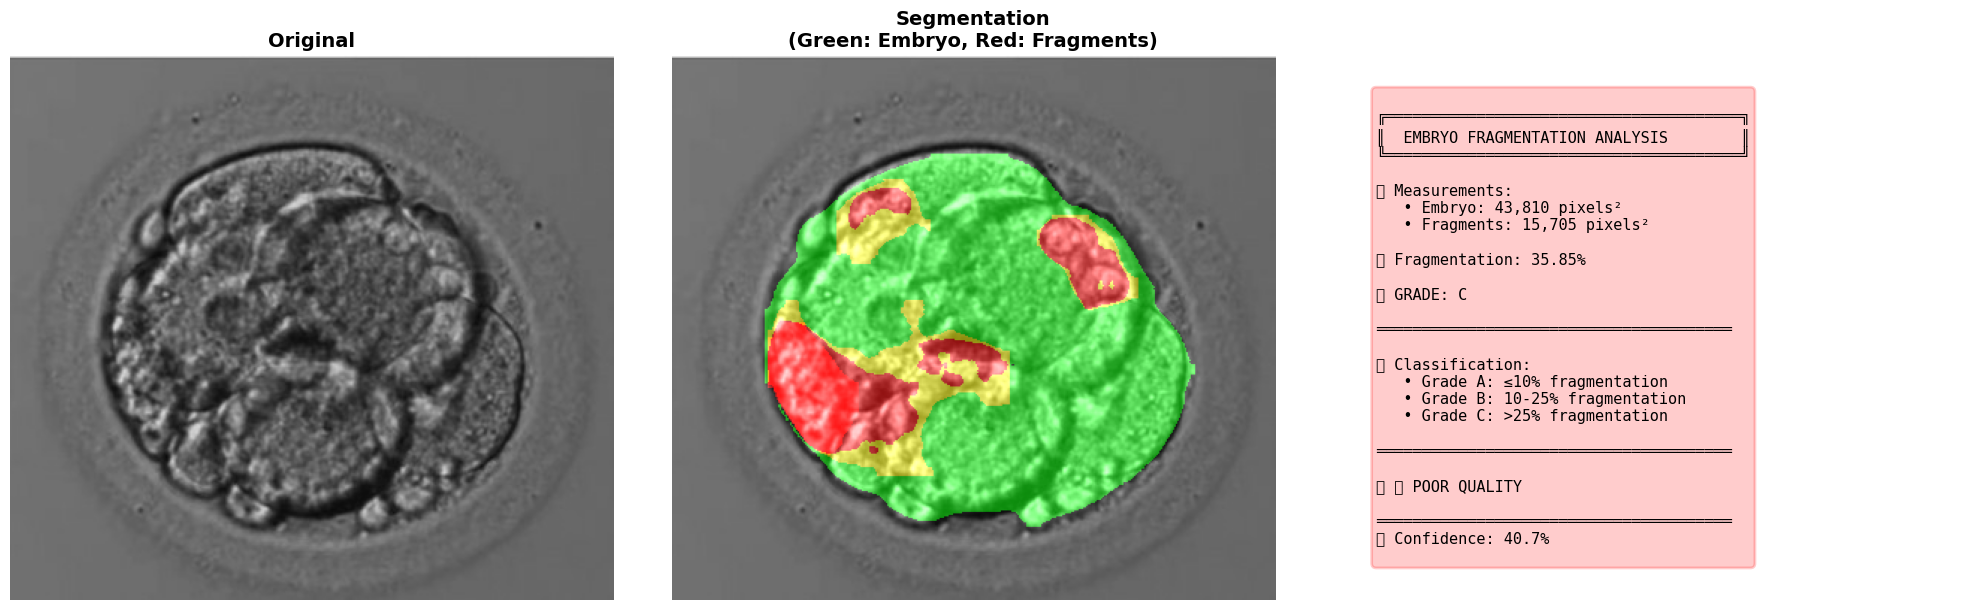

In [3]:
uploaded = files.upload()
for filename in uploaded.keys():
    analyze_embryo(filename)

In [ ]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 42.7 MB/s eta 0:00:00
